<>:202: SyntaxWarning: invalid escape sequence '\m'
<>:202: SyntaxWarning: invalid escape sequence '\m'
/var/folders/p5/ymqv5gy52216l52n9p6467640000gq/T/ipykernel_62541/3482857375.py:202: SyntaxWarning: invalid escape sequence '\m'
  plt.suptitle("SLAG-V GSM $\mathbf{Z=0}$ Plane Density", fontsize=20, y=1.02)


>> Searching for latest Vlasov simulation run...
>> Loading data from /Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/GIFs/Distributional/LinuxRuns/Final/ProtonSim_Vlasov_20260929_121447_plot_data.pkl...
>> Data loaded successfully!
>> Loading GOES-18 orbit data from /Users/nfurioso/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf...
❌ Could not load orbit data (satellite will not be plotted): /Users/nfurioso/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf not found
>> Generating Spatial Evolution Plot (Downsampled to 8 panels)...
Saved: /Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/GIFs/Distributional/LinuxRuns/Final/_Spatial_Evolution.png


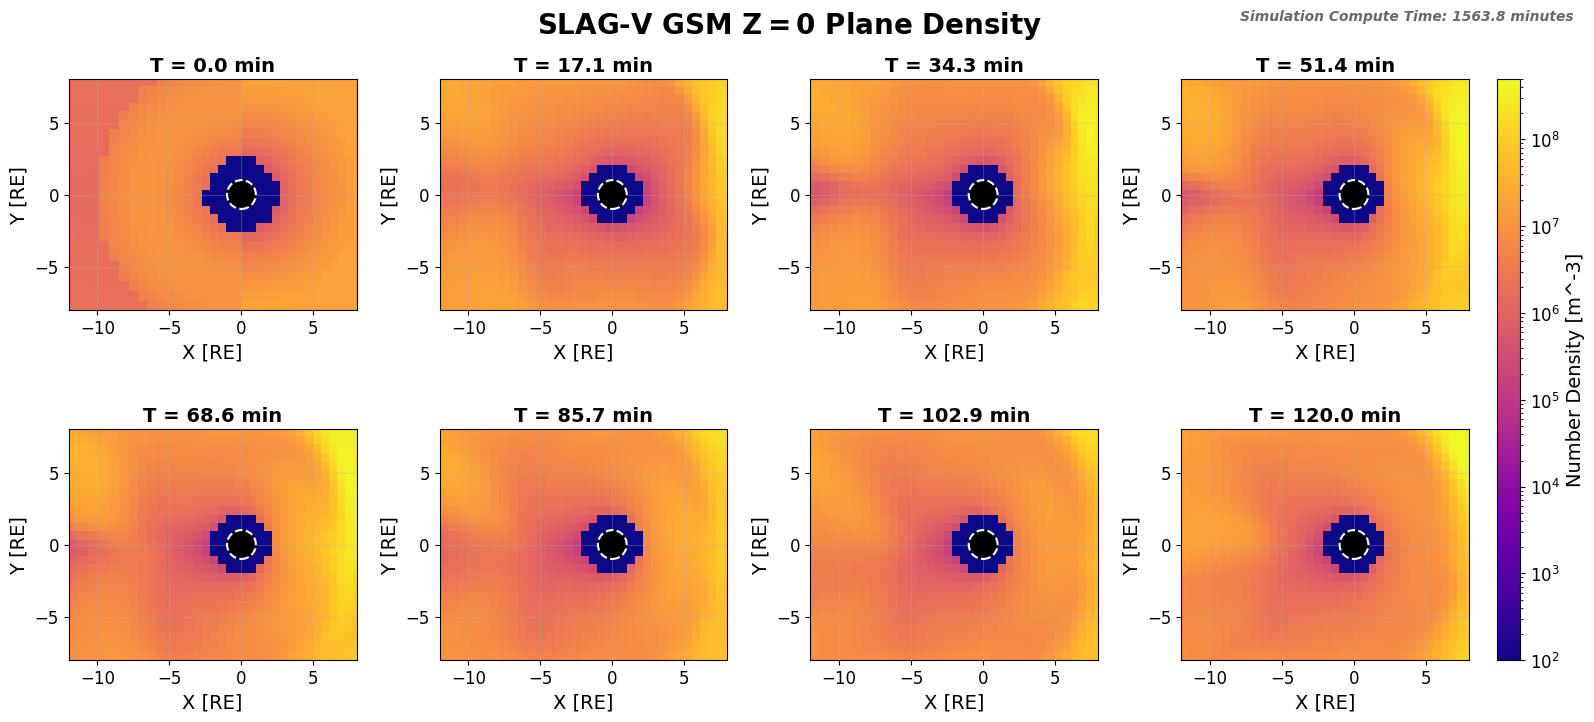

>> Generating Global Diagnostics...
Saved: /Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/GIFs/Distributional/LinuxRuns/Final/_Diagnostics.png


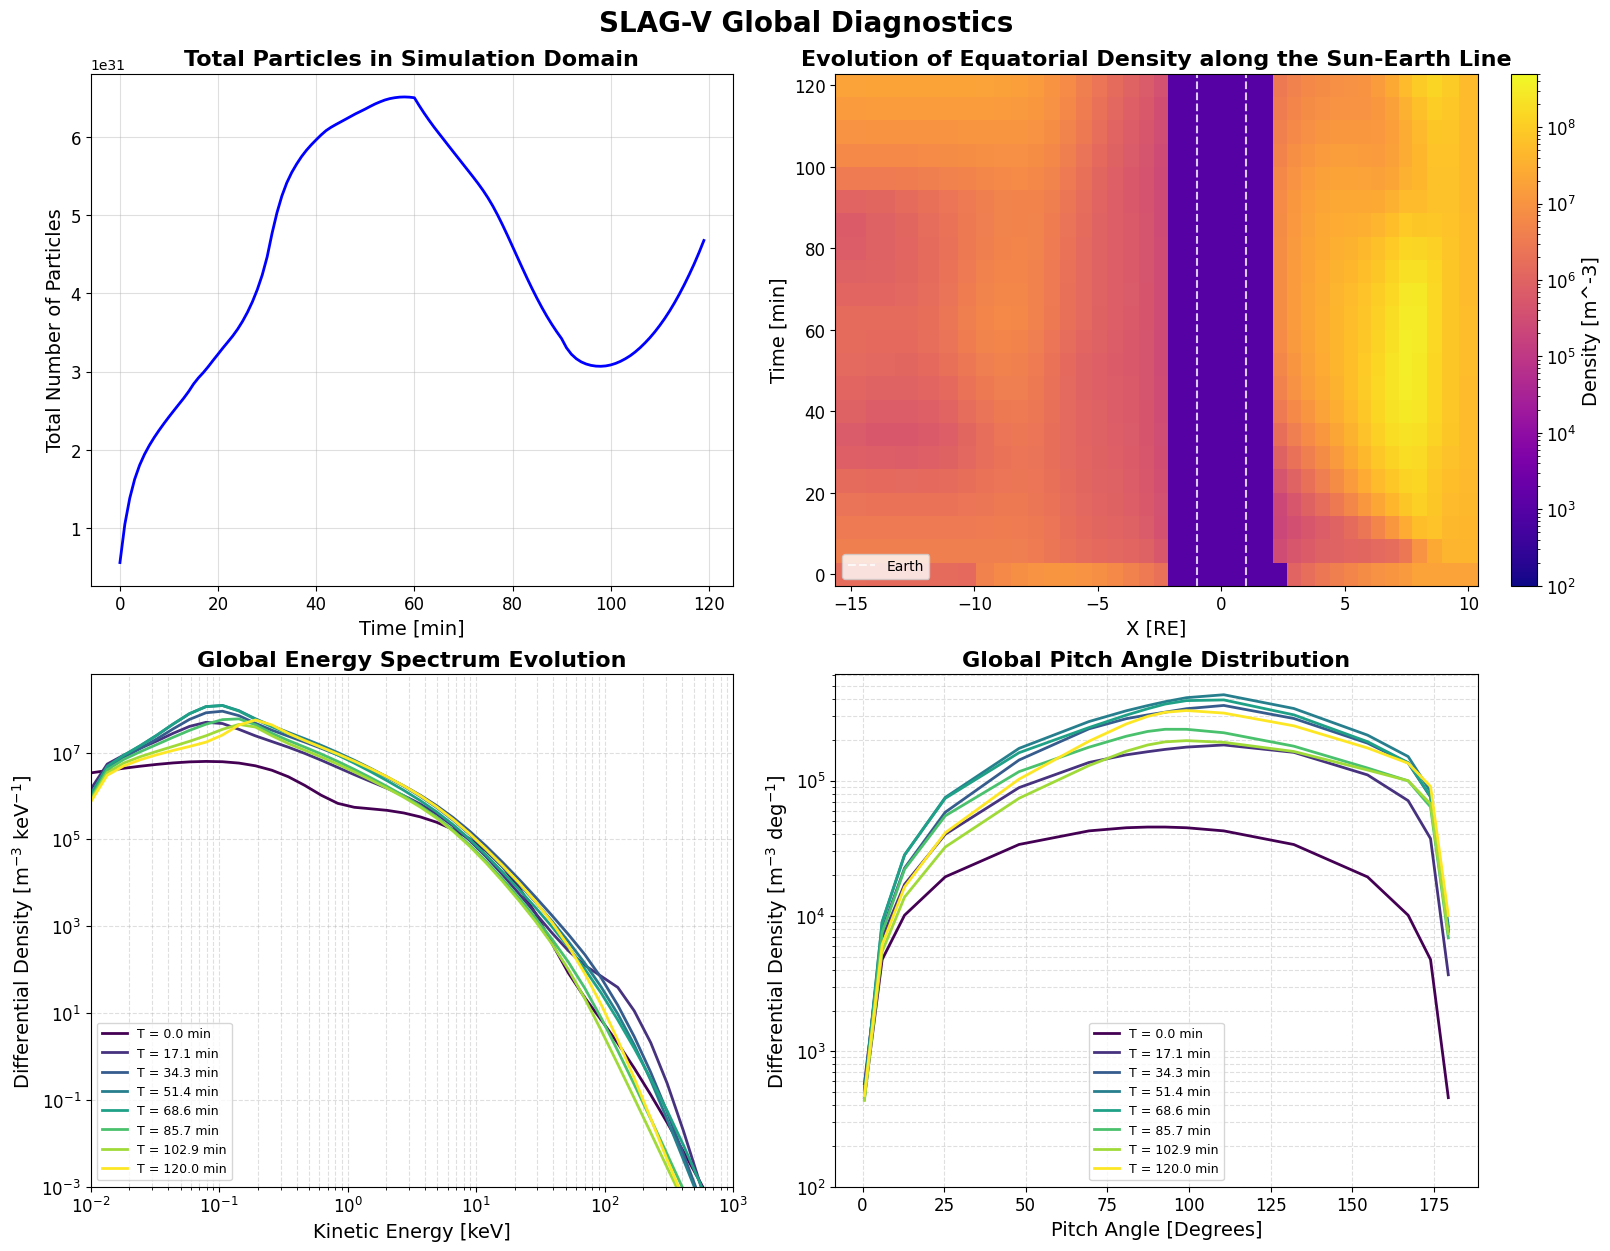

>> Generating GOES-18 Validation Plot...
✅ Success! Forced the h5netcdf backend.
Loading simulation variables from saved CSVs...
>> Median proxy-peak/90-degree flux ratio: 8.17 keV = 1.000, 90 keV = 1.000
>> 8.17-keV proxy peak pitch-angle range: 56.0–98.7 degrees
>> 90-keV proxy peak pitch-angle range: 66.7–90.8 degrees
Saved: /Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/GIFs/Distributional/LinuxRuns/Final/_GOES18_Validation_Vlasov_Directional_Flux.png


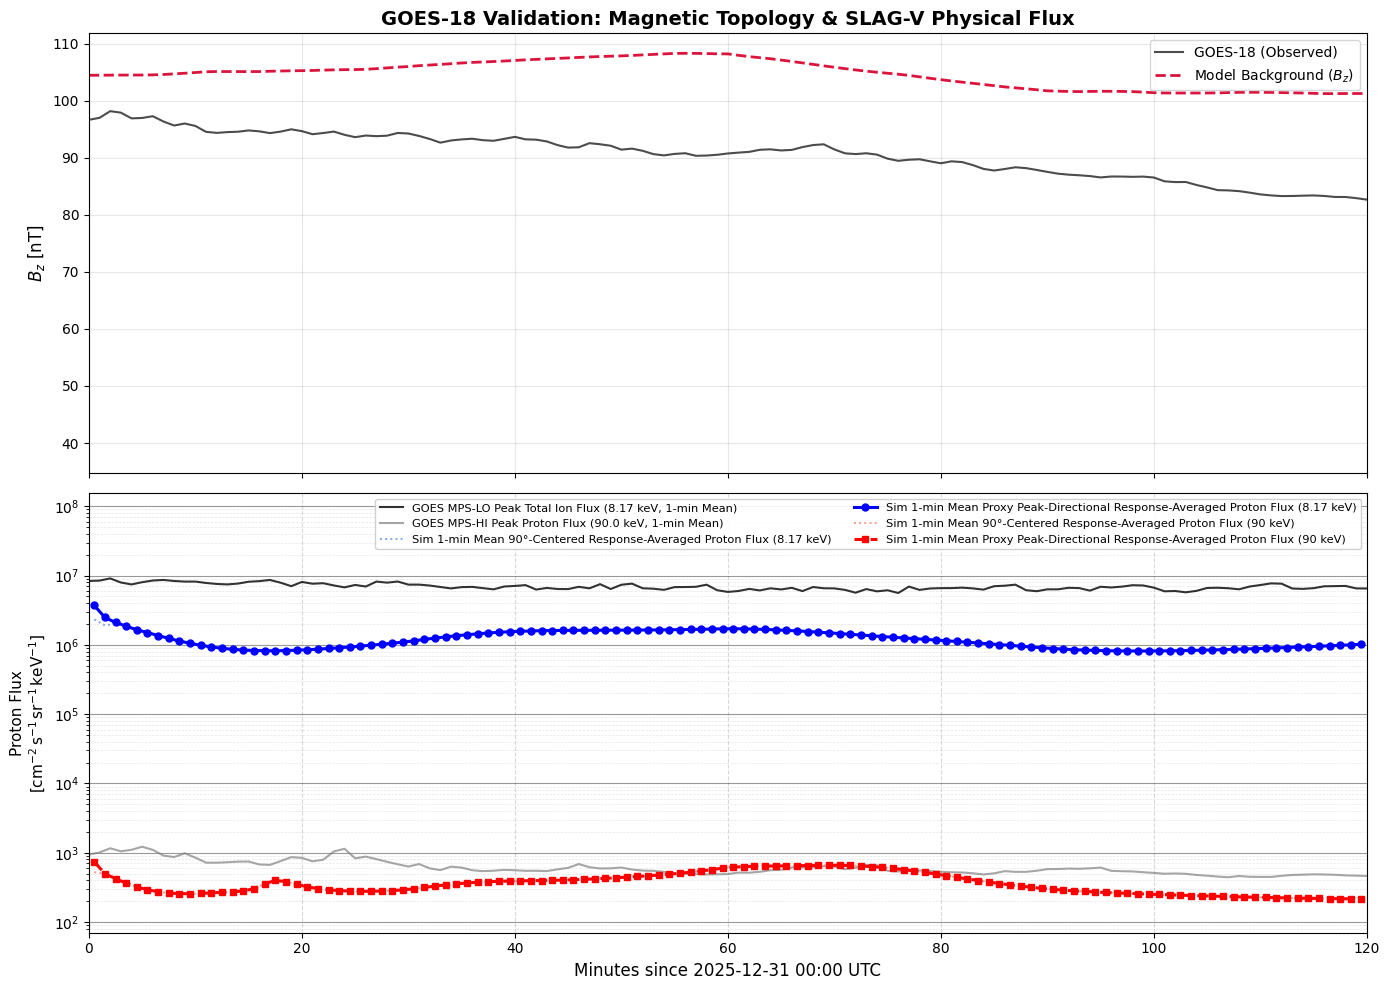

--- Generating Source-Resolved 90-keV Diagnostics ---
Saved: /Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/GIFs/Distributional/LinuxRuns/Final/_GOES18_90keV_Source_Diagnostics.png


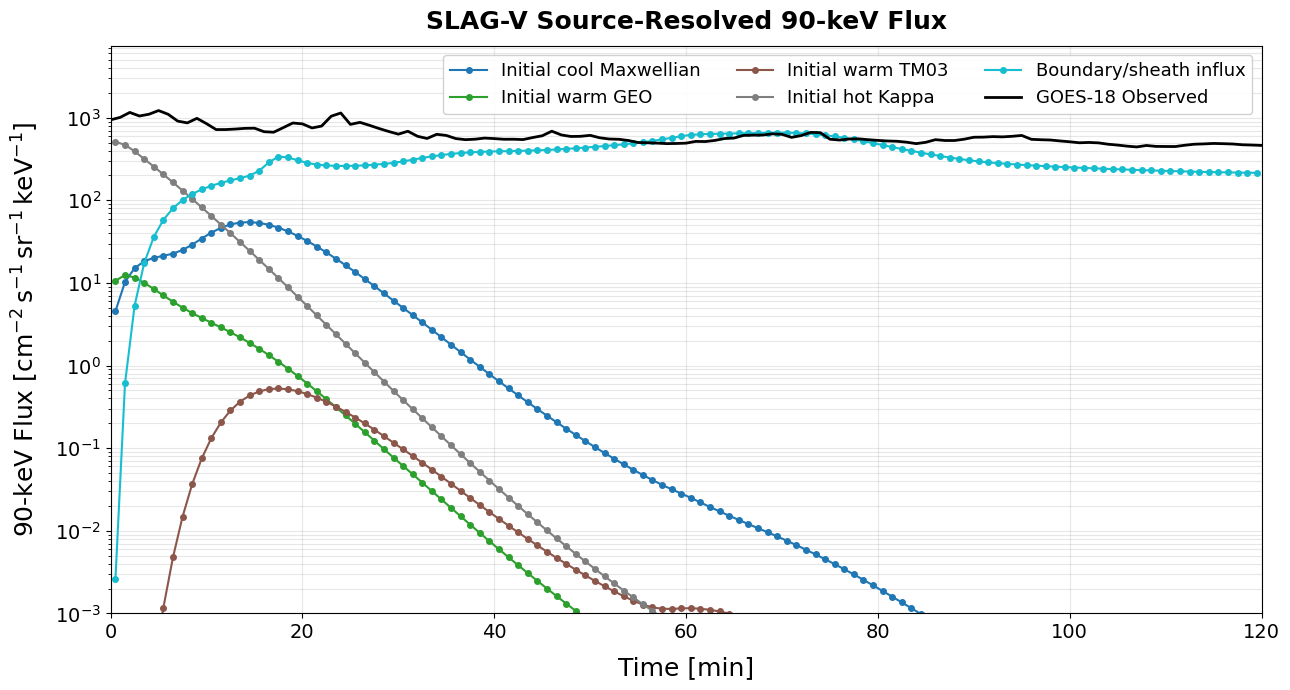

>> All routines completed successfully.


In [12]:
import os
import glob
import pickle
import numpy as np
import xarray as xr
from xarray.backends import H5netcdfBackendEntrypoint
from datetime import datetime, timezone
import cdflib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
import matplotlib.patheffects as pe
import h5netcdf
import matplotlib.ticker as ticker

# =============================================================================
# 1. CONSTANTS & DATA LOADING
# =============================================================================
RE = 6.371e6
q_e = np.float32(1.602e-19)
m_p = np.float32(1.6726219e-27)
sim_start_time = datetime(2025, 12, 31, 0, 0, 0, tzinfo=timezone.utc)
sim_start_unix = sim_start_time.timestamp()

# =============================================================================
# UNIVERSAL DENSITY SCALES (Ensures 1:1 cross-method comparison)
# =============================================================================
DENS_VMIN = 1e2   # Matches the bottom tick in the reference plot
DENS_VMAX = 5e8   # Matches the top extension of the reference colorbar

print(">> Searching for latest Vlasov simulation run...")

#########################################################################################
#########################################################################################
#########################################################################################
# EDIT THIS FOLDER LOCATION
#########################################################################################
#########################################################################################
#########################################################################################
base_dir = "/Users/nfurioso1/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/GIFs/Distributional/LinuxRuns/Final" # EDIT THIS FOLDER LOCATION


run_folders = glob.glob(os.path.join(base_dir, ""))

if not run_folders:
    raise FileNotFoundError(f"No run folders found in {base_dir}!")

# Sort the folders by their modification time, oldest to newest
run_folders.sort(key=os.path.getmtime)

# Automatically grab the newest folder
latest_run_folder = run_folders[-1]
run_folder = latest_run_folder 
base_name = os.path.basename(run_folder).replace("Run_", "ProtonSim_Vlasov_")

pkl_files = glob.glob(os.path.join(latest_run_folder, "*_plot_data.pkl"))
if not pkl_files:
    raise FileNotFoundError(f"No .pkl data file found in {latest_run_folder}")

data_file_path = pkl_files[0]
print(f">> Loading data from {data_file_path}...")

with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

# Unpack Variables
sim_data = data["sim_data"]
mass_times = data["mass_times"]
mass_values = data["mass_values"]
sim_x = data["sim_x"]
sim_y = data["sim_y"]
sim_z = data["sim_z"]
sim_Ek = data["sim_Ek"]
sim_alpha = data["sim_alpha"]
sat_t_sync = data["sat_t_sync"]

print(">> Data loaded successfully!")

# --- ADD GLOBAL PLOT STYLING ---
plt.rcParams.update({
    'axes.titleweight': 'bold',
    'axes.labelweight': 'normal', 
    'figure.titleweight': 'bold',
    'font.weight': 'normal'
})

def save_plot(fig, descriptive_name):
    path = os.path.join(
        run_folder,
        f"{base_name}_{descriptive_name}.png",
    )
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Saved: {path}")

# =========================================================
# ORBIT DATA LOADING (ADDED FOR SATELLITE POSITION)
# =========================================================
orbit_file = "/Users/nfurioso/Library/CloudStorage/OneDrive-UniversityofFlorida/Research/Journal_Paper/GC_motion_in_MHD/goes_data/goes18/orbit/2025/goes18_ephemeris_ssc_20250101_v01.cdf"
print(f">> Loading GOES-18 orbit data from {orbit_file}...")

try:
    orbit_cdf = cdflib.CDF(orbit_file)
    orbit_epoch = orbit_cdf.varget("Epoch")
    orbit_times_unix = cdflib.cdfepoch.unixtime(orbit_epoch)
    
    try:
        orbit_xyz = orbit_cdf.varget("XYZ_GSM")
    except ValueError:
        orbit_xyz = orbit_cdf.varget("XYZ_GSE")
        
    if np.nanmax(np.abs(orbit_xyz)) > 100:
        orbit_xyz = orbit_xyz / 6371.2
        
    print(">> Orbit data loaded successfully.")
except Exception as e:
    print(f"❌ Could not load orbit data (satellite will not be plotted): {e}")
    orbit_times_unix = None
    orbit_xyz = None

# =========================================================
# PLOT 1: Dynamic Spatial Convection Plot (UPDATED FOR 8 PANELS)
# =========================================================
print(">> Generating Spatial Evolution Plot (Downsampled to 8 panels)...")

if 'compute_time_minutes' in data:
    compute_str = f"Simulation Compute Time: {data['compute_time_minutes']:.1f} minutes"
else:
    compute_str = "Simulation Compute Time: Unknown"

n_snaps = len(sim_data)
target_panels = 8

# Generate exactly 8 indices spanning from the first to the last frame safely
if n_snaps > target_panels:
    plot_indices = np.linspace(0, n_snaps - 1, target_panels, dtype=int)
else:
    plot_indices = np.arange(n_snaps)

cols = 4
rows = int(np.ceil(len(plot_indices) / cols))

# Adjusted figure size slightly to maintain excellent aspect ratios for journal columns
fig1, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows), constrained_layout=True)
if rows == 1: axes = np.expand_dims(axes, axis=0)
ax_flat = axes.flatten()

z_idx = len(sim_z) // 2 
valid_maxes = [np.nanmax(s['dens_3d']) for s in sim_data if not np.all(np.isnan(s['dens_3d']))]
max_val = np.nanmax(valid_maxes) if valid_maxes else 1e4 

for idx_count, sim_idx in enumerate(plot_indices):
    ax = ax_flat[idx_count]
    snap = sim_data[sim_idx]
    dens_2d = snap['dens_3d'][:, :, z_idx]
    
    dens_2d_safe = np.where(dens_2d <= 0, 1e-10, dens_2d)
    dens_2d_masked = np.ma.masked_invalid(dens_2d_safe.T)
    
    im = ax.pcolormesh(sim_x/RE, sim_y/RE, dens_2d_masked, 
                       shading='nearest', cmap='plasma', 
                       norm=LogNorm(vmin=DENS_VMIN, vmax=DENS_VMAX))
    
    # Draw Earth
    earth_mask = plt.Circle((0, 0), 1.0, color='black', zorder=10)
    earth_outline = plt.Circle((0, 0), 1.0, color='white', fill=False, linestyle='--', linewidth=1.5, zorder=11)
    ax.add_patch(earth_mask)
    ax.add_patch(earth_outline)
    
    # Plot Orbit Path and Satellite Position
    if orbit_times_unix is not None and orbit_xyz is not None:
        snap_unix = sim_start_unix + snap['time']
        half_day = 12 * 3600
        time_mask = (orbit_times_unix >= snap_unix - half_day) & (orbit_times_unix <= snap_unix + half_day)
        
        ax.plot(orbit_xyz[time_mask, 0], orbit_xyz[time_mask, 1], 
                color='black', linestyle='--', linewidth=1.5, zorder=12, alpha=0.8,
                path_effects=[pe.withStroke(linewidth=3, foreground="white")])
        
        sat_x = np.interp(snap_unix, orbit_times_unix, orbit_xyz[:, 0])
        sat_y = np.interp(snap_unix, orbit_times_unix, orbit_xyz[:, 1])
        
        ax.plot(sat_x, sat_y, marker='*', color='white', markersize=12, markeredgecolor='black', zorder=15)
        ax.text(sat_x + 0.4, sat_y + 0.4, 'GOES-18', color='white', fontsize=9, fontweight='bold', zorder=15,
                path_effects=[pe.withStroke(linewidth=2, foreground="black")])

    ax.set_title(f"T = {snap['time'] / 60.0:.1f} min", fontsize=14, fontweight='bold')
    ax.set_xlabel("X [RE]", fontsize=14)
    ax.set_ylabel("Y [RE]", fontsize=14)
    ax.tick_params(labelsize=12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-8, 8); ax.set_xlim(-12, 8)

# Hide any remaining empty subplots if target_panels doesn't divide evenly by cols
for empty_idx in range(len(plot_indices), len(ax_flat)):
    ax_flat[empty_idx].set_visible(False)

# --- UPDATED COLORBAR (Taller, wider, and larger text) ---
cbar = fig1.colorbar(im, ax=axes, location='right', shrink=0.85, aspect=25, pad=0.02)
cbar.set_label("Number Density [m^-3]", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.suptitle("SLAG-V GSM $\mathbf{Z=0}$ Plane Density", fontsize=20, y=1.02)

fig1.text(0.99, 1.02, compute_str, ha='right', va='top', 
         fontsize=10, color='dimgray', style='italic', weight='bold')

save_plot(fig1, "Spatial_Evolution")
plt.show(block=False)

# =========================================================
# PLOT 2: The 4-Panel Global Diagnostics Dashboard
# =========================================================
print(">> Generating Global Diagnostics...")
fig2, axs = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
times_min = np.array([s['time'] / 60.0 for s in sim_data])
x_slices = np.array([s['x_slice'] for s in sim_data]) 

# Panel A
mass_times_min = mass_times / 60.0
axs[0,0].plot(mass_times_min, mass_values, 'b-', linewidth=2)
axs[0,0].set_title("Total Particles in Simulation Domain", fontweight='bold', fontsize=16)
axs[0,0].set_xlabel("Time [min]", fontsize=14)
axs[0,0].set_ylabel("Total Number of Particles", fontsize=14)
axs[0,0].tick_params(labelsize=12)
axs[0,0].grid(True, alpha=0.4)

# Panel B
x_slices_filled = np.nan_to_num(x_slices, nan=1e3, posinf=1e3, neginf=1e3)
x_slices_filled = np.where(x_slices_filled < 1e3, 1e3, x_slices_filled)

im_hov = axs[0,1].pcolormesh(sim_x/RE, times_min, x_slices_filled, 
                             shading='auto', cmap='plasma', 
                             norm=LogNorm(vmin=DENS_VMIN, vmax=DENS_VMAX))
                             
axs[0,1].axvline(x=1.0, color='w', linestyle='--', alpha=0.8, label='Earth')
axs[0,1].axvline(x=-1.0, color='w', linestyle='--', alpha=0.8)
axs[0,1].set_title("Evolution of Equatorial Density along the Sun-Earth Line", fontweight='bold', fontsize=16)
axs[0,1].set_xlabel("X [RE]", fontsize=14)
axs[0,1].set_ylabel("Time [min]", fontsize=14)
axs[0,1].tick_params(labelsize=12)

cbar_hov = fig2.colorbar(im_hov, ax=axs[0,1])
cbar_hov.set_label('Density [m^-3]', fontsize=14)
cbar_hov.ax.tick_params(labelsize=12)
axs[0,1].legend(loc='lower left', fontsize=10)

# Panels C & D
num_lines = min(8, len(sim_data))
indices = np.linspace(0, len(sim_data) - 1, num_lines, dtype=int)
colors = plt.cm.viridis(np.linspace(0, 1, num_lines))

sim_Ek_keV = sim_Ek / (1000.0 * q_e)

for idx, color in zip(indices, colors):
    snap = sim_data[idx]
    t_label = f"T = {snap['time']/60.0:.1f} min"
    
    axs[1,0].plot(sim_Ek_keV, snap['spec_E'], color=color, label=t_label, linewidth=2)
    axs[1,1].plot(np.degrees(sim_alpha), snap['spec_alpha'], color=color, label=t_label, linewidth=2)

# Format Panel C
axs[1,0].set_xscale('log')
axs[1,0].set_yscale('log')
axs[1,0].set_title("Global Energy Spectrum Evolution", fontweight='bold', fontsize=16)
axs[1,0].set_xlabel("Kinetic Energy [keV]", fontsize=14)
axs[1,0].set_ylabel("Differential Density [m$^{-3}$ keV$^{-1}$]", fontsize=14)
axs[1,0].tick_params(labelsize=12)
axs[1,0].grid(True, which="both", ls="--", alpha=0.4)
axs[1,0].set_xlim(0.01, 1000) 
axs[1,0].set_ylim(bottom=1e-3) 
if num_lines <= 10: 
    axs[1,0].legend(fontsize=9, loc='lower left', ncol=2 if num_lines > 10 else 1)

# Format Panel D
axs[1,1].set_yscale('log')
axs[1,1].set_title("Global Pitch Angle Distribution", fontweight='bold', fontsize=16)
axs[1,1].set_xlabel("Pitch Angle [Degrees]", fontsize=14)
axs[1,1].set_ylabel("Differential Density [m$^{-3}$ deg$^{-1}$]", fontsize=14)
axs[1,1].tick_params(labelsize=12)
axs[1,1].set_ylim(bottom=100) 
axs[1,1].grid(True, which="both", ls="--", alpha=0.4)
if num_lines <= 10: 
    axs[1,1].legend(fontsize=9, loc='lower center', ncol=2 if num_lines > 10 else 1)

plt.suptitle("SLAG-V Global Diagnostics", fontsize=20, y=1.03)
save_plot(fig2, "Diagnostics")
plt.show(block=False)

# =========================================================
# PLOT 3: VIRTUAL SATELLITE VALIDATION (GOES-18)
# =========================================================
print(">> Generating GOES-18 Validation Plot...")

# 1. Load Satellite Data
base_dir = "goes_data/goes18"
mag_file = f"{base_dir}/l2/data/magn-l2-avg1m/2025/12/dn_magn-l2-avg1m_g18_d20251231_v2-0-4.nc"
mpsh_file = f"{base_dir}/l2/data/mpsh-l2-avg1m/2025/12/ops_seis-l1b-mpsh_g18_d20251231_v0-0-0.nc"
mpsl_file = f"{base_dir}/l2/data/mpsl-l2-avg1m/2025/12/ops_seis-l1b-mpsl_g18_d20251231_v0-0-0.nc"

try:
    ds_mag = xr.open_dataset(mag_file, engine=H5netcdfBackendEntrypoint)
    ds_mpsh = xr.open_dataset(mpsh_file, engine=H5netcdfBackendEntrypoint)
    ds_mpsl = xr.open_dataset(mpsl_file, engine=H5netcdfBackendEntrypoint)
    print("✅ Success! Forced the h5netcdf backend.")
except Exception as e:
    print(f"❌ Could not load GOES data. Make sure files are present.\nError: {e}")
    ds_mag = xr.Dataset({'b_gsm': (['time', 'dim'], np.zeros((1, 3))), 'time': [0]})
    ds_mpsh = xr.Dataset({'AvgDiffProtonFlux': (['time', 'dim'], np.zeros((1, 1))), 'time': [0]})
    ds_mpsl = xr.Dataset({'DiffIonFluxes': (['time', 'dim'], np.zeros((1, 11))), 'time': [0]})

obs_times_unix = ds_mag['time'].values.astype('datetime64[s]').astype(np.float64)
t_sync_norm = obs_times_unix - sim_start_unix

# Extract Observational Truth Values
obs_bz = ds_mag['b_gsm'].values[:, 2]

# ---------------------------------------------------------
# --- GOES SATELLITE DATA FIX: PEAK FLUX (nanmax) ---
# ---------------------------------------------------------
# 1. MPS-HI (90 keV): Extract directional L1b variable and find the peak telescope
flux_hi_raw = ds_mpsh['DiffProtonFluxes'].values
flux_hi_peak = np.nanmax(flux_hi_raw, axis=1) if flux_hi_raw.ndim == 3 else flux_hi_raw

# Apply 1-minute median smoothing to match the simulation macro-state
start_dt64 = np.datetime64('2025-12-31T00:00:00')
l1b_time_hi = start_dt64 + np.arange(flux_hi_peak.shape[0]) * np.timedelta64(1, 's')
da_flux_hi = xr.DataArray(flux_hi_peak, coords={'time': l1b_time_hi}, dims=['time', 'energy'])
da_flux_hi_1min = da_flux_hi.resample(time='1Min').mean()

obs_flux_hi = da_flux_hi_1min.values[:, 0] 
obs_flux_hi_times_unix = da_flux_hi_1min['time'].values.astype('datetime64[s]').astype(np.float64)

flux_lo_raw = ds_mpsl['DiffIonFluxes'].values
# CHANGED: nanmean -> nanmax to extract the peak zone
flux_lo_peak = np.nanmax(flux_lo_raw, axis=1) if flux_lo_raw.ndim == 3 else flux_lo_raw

start_dt64 = np.datetime64('2025-12-31T00:00:00')
l1b_time = start_dt64 + np.arange(flux_lo_peak.shape[0]) * np.timedelta64(1, 's')
da_flux_lo = xr.DataArray(flux_lo_peak, coords={'time': l1b_time}, dims=['time', 'energy'])

da_flux_lo_1min = da_flux_lo.resample(time='1Min').mean()

# Shifted from index 10 (4.88 keV) to index 11 (8.17 keV) to better match the 10 keV sim
obs_flux_lo = da_flux_lo_1min.values[:, 11] if da_flux_lo_1min.values.shape[1] > 11 else np.zeros_like(da_flux_lo_1min.values[:, 0])
obs_flux_lo_times_unix = da_flux_lo_1min['time'].values.astype('datetime64[s]').astype(np.float64)

# =============================================================================
# 2. LOAD MODEL OUTPUTS FROM SAVED CSV FILES
# =============================================================================
print("Loading simulation variables from saved CSVs...")


def positive_or_nan(values):
    """Replace nonfinite and nonpositive values for logarithmic plotting."""
    values = np.asarray(values, dtype=np.float64)

    return np.where(
        np.isfinite(values) & (values > 0.0),
        values,
        np.nan,
    )


# -----------------------------------------------------------------------------
# Load modeled magnetic field
# -----------------------------------------------------------------------------
bz_csv_path = os.path.join(
    run_folder,
    "model_A_bz.csv",
)

try:
    bz_data = np.loadtxt(
        bz_csv_path,
        delimiter=",",
        skiprows=1,
    )

    bz_data = np.atleast_2d(bz_data)

    csv_t_axis_min = bz_data[:, 0]
    model_bz = bz_data[:, 1]

except FileNotFoundError:
    print(
        f"Warning: {bz_csv_path} not found. "
        "Skipping model Bz line."
    )

    csv_t_axis_min = t_sync_norm / 60.0
    model_bz = np.full_like(
        csv_t_axis_min,
        np.nan,
        dtype=np.float64,
    )


# -----------------------------------------------------------------------------
# Load modeled proton-flux products
# -----------------------------------------------------------------------------
flux_csv_path = os.path.join(
    run_folder,
    "model_A_vlasov_fluxes.csv",
)

try:
    flux_table = np.genfromtxt(
        flux_csv_path,
        delimiter=",",
        names=True,
        dtype=np.float64,
        encoding=None,
    )

    flux_table = np.atleast_1d(flux_table)

    if flux_table.dtype.names is None:
        raise RuntimeError(
            "The model flux CSV does not contain a readable header."
        )

    available_columns = flux_table.dtype.names

    required_columns = (
        "time_min",
        "flux_8p17keV_90deg_all_sources",
        "flux_90keV_90deg_all_sources",
        "flux_8p17keV_proxy_peak_directional_all_sources",
        "flux_90keV_proxy_peak_directional_all_sources",
        "peak_pitch_8p17_deg",
        "peak_pitch_90_deg",
    )

    missing_columns = [
        column
        for column in required_columns
        if column not in available_columns
    ]

    if missing_columns:
        raise RuntimeError(
            "The model flux CSV is missing these columns: "
            f"{missing_columns}\n"
            f"Available columns: {available_columns}\n"
            "Make sure the selected run was generated with the "
            "updated simulation export code."
        )

    # Time axis: one-minute bin centers.
    model_time_min = np.asarray(
        flux_table["time_min"],
        dtype=np.float64,
    )

    # All-source 90-degree-centered products.
    model_flux_8p17_90deg = np.asarray(
        flux_table["flux_8p17keV_90deg_all_sources"],
        dtype=np.float64,
    )

    model_flux_90_90deg = np.asarray(
        flux_table["flux_90keV_90deg_all_sources"],
        dtype=np.float64,
    )

    # All-source proxy peak-directional products.
    model_flux_8p17_peak = np.asarray(
        flux_table[
            "flux_8p17keV_proxy_peak_directional_all_sources"
        ],
        dtype=np.float64,
    )

    model_flux_90_peak = np.asarray(
        flux_table[
            "flux_90keV_proxy_peak_directional_all_sources"
        ],
        dtype=np.float64,
    )

    # Pitch angles selected by the peak-directional calculation.
    model_peak_pitch_8p17_deg = np.asarray(
        flux_table["peak_pitch_8p17_deg"],
        dtype=np.float64,
    )

    model_peak_pitch_90_deg = np.asarray(
        flux_table["peak_pitch_90_deg"],
        dtype=np.float64,
    )

    # Optional legacy and diagnostic columns.
    sim_goes_flux_lo_all = np.asarray(
        flux_table["flux_8p17keV_all_sources"],
        dtype=np.float64,
    )

    sim_goes_flux_hi_initial_hot = np.asarray(
        flux_table["flux_90keV_initial_hot"],
        dtype=np.float64,
    )

    sim_goes_flux_hi_all = np.asarray(
        flux_table["flux_90keV_all_sources"],
        dtype=np.float64,
    )

    detector_kernel_weight = np.asarray(
        flux_table["spatial_kernel_weight"],
        dtype=np.float64,
    )

    detector_sample_count = np.asarray(
        flux_table["sample_count"],
        dtype=np.float64,
    )

except FileNotFoundError as exc:
    raise FileNotFoundError(
        f"The model flux file was not found: {flux_csv_path}"
    ) from exc


# -----------------------------------------------------------------------------
# Clean flux arrays for logarithmic plotting
# -----------------------------------------------------------------------------
model_flux_8p17_90deg = positive_or_nan(
    model_flux_8p17_90deg
)

model_flux_90_90deg = positive_or_nan(
    model_flux_90_90deg
)

model_flux_8p17_peak = positive_or_nan(
    model_flux_8p17_peak
)

model_flux_90_peak = positive_or_nan(
    model_flux_90_peak
)

sim_goes_flux_lo_all = positive_or_nan(
    sim_goes_flux_lo_all
)

sim_goes_flux_hi_initial_hot = positive_or_nan(
    sim_goes_flux_hi_initial_hot
)

sim_goes_flux_hi_all = positive_or_nan(
    sim_goes_flux_hi_all
)


# -----------------------------------------------------------------------------
# Validate array lengths
# -----------------------------------------------------------------------------
model_arrays = {
    "model_flux_8p17_90deg": model_flux_8p17_90deg,
    "model_flux_90_90deg": model_flux_90_90deg,
    "model_flux_8p17_peak": model_flux_8p17_peak,
    "model_flux_90_peak": model_flux_90_peak,
    "model_peak_pitch_8p17_deg": model_peak_pitch_8p17_deg,
    "model_peak_pitch_90_deg": model_peak_pitch_90_deg,
}

for array_name, array_values in model_arrays.items():
    if len(array_values) != len(model_time_min):
        raise RuntimeError(
            f"{array_name} has {len(array_values)} entries, "
            f"but model_time_min has {len(model_time_min)}."
        )


# -----------------------------------------------------------------------------
# Print useful directional diagnostics
# -----------------------------------------------------------------------------
valid_8p17_ratio = (
    np.isfinite(model_flux_8p17_peak)
    & np.isfinite(model_flux_8p17_90deg)
    & (model_flux_8p17_90deg > 0.0)
)

valid_90_ratio = (
    np.isfinite(model_flux_90_peak)
    & np.isfinite(model_flux_90_90deg)
    & (model_flux_90_90deg > 0.0)
)

median_ratio_8p17 = np.nan
median_ratio_90 = np.nan

if np.any(valid_8p17_ratio):
    median_ratio_8p17 = np.nanmedian(
        model_flux_8p17_peak[valid_8p17_ratio]
        / model_flux_8p17_90deg[valid_8p17_ratio]
    )

if np.any(valid_90_ratio):
    median_ratio_90 = np.nanmedian(
        model_flux_90_peak[valid_90_ratio]
        / model_flux_90_90deg[valid_90_ratio]
    )

print(
    ">> Median proxy-peak/90-degree flux ratio: "
    f"8.17 keV = {median_ratio_8p17:.3f}, "
    f"90 keV = {median_ratio_90:.3f}"
)

if np.any(np.isfinite(model_peak_pitch_8p17_deg)):
    print(
        ">> 8.17-keV proxy peak pitch-angle range: "
        f"{np.nanmin(model_peak_pitch_8p17_deg):.1f}–"
        f"{np.nanmax(model_peak_pitch_8p17_deg):.1f} degrees"
    )

if np.any(np.isfinite(model_peak_pitch_90_deg)):
    print(
        ">> 90-keV proxy peak pitch-angle range: "
        f"{np.nanmin(model_peak_pitch_90_deg):.1f}–"
        f"{np.nanmax(model_peak_pitch_90_deg):.1f} degrees"
    )


# =============================================================================
# RENDER VALIDATION PLOT
# =============================================================================
fig_v, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True,
)

t_axis_min = t_sync_norm / 60.0


# Panel 1: Magnetometer
ax1.plot(
    t_axis_min,
    obs_bz,
    color="black",
    label="GOES-18 (Observed)",
    alpha=0.7,
)

ax1.plot(
    csv_t_axis_min,
    model_bz,
    color="crimson",
    linestyle="--",
    label=r"Model Background ($B_z$)",
    linewidth=2,
)

ax1.set_ylabel(r"$B_z$ [nT]", fontsize=12)
ax1.set_title(
    "GOES-18 Validation: Magnetic Topology & SLAG-V Physical Flux",
    fontweight="bold",
    fontsize=14,
)
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)


# Panel 2: GOES observations
ax2.plot(
    (obs_flux_lo_times_unix - sim_start_unix) / 60.0,
    positive_or_nan(obs_flux_lo),
    color="black",
    linewidth=1.5,
    alpha=0.8,
    label=(
        "GOES MPS-LO Peak Total Ion Flux "
        "(8.17 keV, 1-min Mean)"
    ),
)

ax2.plot(
    (obs_flux_hi_times_unix - sim_start_unix) / 60.0,
    positive_or_nan(obs_flux_hi),
    color="gray",
    linewidth=1.5,
    alpha=0.7,
    label=(
        "GOES MPS-HI Peak Proton Flux "
        "(90.0 keV, 1-min Mean)"
    ),
)


# Model: 90-degree-centered reference at 8.17 keV
ax2.plot(
    model_time_min,
    model_flux_8p17_90deg,
    color="cornflowerblue",
    linestyle=":",
    linewidth=1.4,
    alpha=0.8,
    label=(
        "Sim 1-min Mean 90°-Centered Response-Averaged "
        "Proton Flux (8.17 keV)"
    ),
)


# Model: proxy peak-directional result at 8.17 keV
ax2.plot(
    model_time_min,
    model_flux_8p17_peak,
    color="blue",
    linestyle="-",
    linewidth=2.2,
    marker="o",
    markersize=5,
    label=(
        "Sim 1-min Mean Proxy Peak-Directional "
        "Response-Averaged Proton Flux (8.17 keV)"
    ),
)


# Model: 90-degree-centered reference at 90 keV
ax2.plot(
    model_time_min,
    model_flux_90_90deg,
    color="salmon",
    linestyle=":",
    linewidth=1.4,
    alpha=0.8,
    label=(
        "Sim 1-min Mean 90°-Centered Response-Averaged "
        "Proton Flux (90 keV)"
    ),
)


# Model: proxy peak-directional result at 90 keV
ax2.plot(
    model_time_min,
    model_flux_90_peak,
    color="red",
    linestyle="--",
    linewidth=2.2,
    marker="s",
    markersize=5,
    label=(
        "Sim 1-min Mean Proxy Peak-Directional "
        "Response-Averaged Proton Flux (90 keV)"
    ),
)


ax2.set_ylabel(
    "Proton Flux\n"
    r"$[\mathrm{cm}^{-2}\,\mathrm{s}^{-1}\,"
    r"\mathrm{sr}^{-1}\,\mathrm{keV}^{-1}]$",
    fontsize=11,
)

ax2.set_yscale("log")

ax2.legend(
    loc="best",
    ncol=2,
    fontsize=8.2,
    framealpha=0.9,
)

ax2.grid(
    True,
    axis="x",
    which="major",
    color="gray",
    alpha=0.3,
    linestyle="--",
)

ax2.grid(
    True,
    axis="y",
    which="major",
    color="black",
    alpha=0.4,
    linestyle="-",
    linewidth=0.8,
)

ax2.grid(
    True,
    axis="y",
    which="minor",
    color="gray",
    alpha=0.2,
    linestyle="--",
    linewidth=0.5,
)

ax2.yaxis.set_minor_locator(
    ticker.LogLocator(
        base=10.0,
        subs=np.arange(2, 10) * 0.1,
        numticks=100,
    )
)

ax2.set_xlabel(
    "Minutes since 2025-12-31 00:00 UTC",
    fontsize=12,
)

ax2.set_xlim(
    0.0,
    np.nanmax(model_time_min) + 0.5,
)

plt.tight_layout()
save_plot(
    fig_v,
    "GOES18_Validation_Vlasov_Directional_Flux",
)
plt.show()

# =============================================================================
# SOURCE-RESOLVED 90-keV DIAGNOSTICS (Adapted from GC format)
# =============================================================================
print("--- Generating Source-Resolved 90-keV Diagnostics ---")

source_csv_path = os.path.join(run_folder, "model_A_vlasov_fluxes_by_source.csv")

try:
    source_data = np.loadtxt(source_csv_path, delimiter=",", skiprows=1)
    time_min = source_data[:, 0]
    positive_time = time_min >= 0.0
    time_min_pos = time_min[positive_time]

    source_names = [
        "Initial cool Maxwellian",
        "Initial warm GEO",
        "Initial warm TM03",
        "Initial hot Kappa",
        "Boundary/sheath influx"
    ]
    source_colors = plt.cm.tab10(np.linspace(0, 1, len(source_names)))

    # 1. Increased figure width/height for better breathing room
    fig_diag, ax_flux = plt.subplots(1, 1, figsize=(13, 7))

    for i, (name, color) in enumerate(zip(source_names, source_colors)):
        flux = source_data[:, i + 1][positive_time]
        
        # Clean zeros for log scale
        zeros = flux <= 0.0
        flux_plot = flux.copy()
        flux_plot[zeros] = np.nan
        
        ax_flux.plot(
            time_min_pos, flux_plot, 
            marker="o", markersize=4, linewidth=1.5, 
            color=color, label=name
        )

    # Plot empirical observation against the source distributions
    ax_flux.plot(
        (obs_flux_hi_times_unix - sim_start_unix) / 60.0, 
        obs_flux_hi, 
        color="black", linewidth=2.0, label="GOES-18 Observed",
    )
    
    ax_flux.set(yscale="log", ylim=(1e-3, None))
    
    # 2. Explicitly formatted title, axis labels, and padding
    ax_flux.set_title(
        "SLAG-V Source-Resolved 90-keV Flux", 
        fontsize=18, 
        fontweight="bold", 
        pad=12
    )
    ax_flux.set_xlabel(
        "Time [min]", 
        fontsize=18, 
        labelpad=10
    )
    ax_flux.set_ylabel(
        r"90-keV Flux [$\mathrm{cm^{-2}\,s^{-1}\,sr^{-1}\,keV^{-1}}$]", 
        fontsize=18, 
        labelpad=10
    )
    
    # 3. Increased tick number label size for readability
    ax_flux.tick_params(axis='both', which='major', labelsize=14)
    
    ax_flux.grid(True, which="both", alpha=0.3)
    ax_flux.legend(fontsize=13, loc='best', ncol=3, framealpha=0.9)
    
    plt.xlim(0.0, np.nanmax(time_min_pos) + 0.5) 
    plt.tight_layout()
    
    save_plot(fig_diag, "GOES18_90keV_Source_Diagnostics")
    plt.show()

except FileNotFoundError:
    print(f"Warning: {source_csv_path} not found. Skipping source-resolved plot.")
except Exception as e:
    print(f"Error generating source-resolved plot: {e}")


print(">> All routines completed successfully.")